# Changepoint Detection: Finding Regime Shifts in Financial Data
Detect volatility regime shifts in the S&P 500 using the PELT algorithm in Python. Compare PELT with Binary Segmentation, tune the penalty parameter, and align detected changepoints with real financial crises.

In [1]:
!pip install -q yfinance ruptures matplotlib numpy pandas scipy

## 1. Download S&P 500 Data
40 years of daily data covering Black Monday, the dot-com bubble, the GFC, COVID, and the 2022 rate hike sell-off.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import ruptures as rpt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sp = yf.download("^GSPC", start="1984-12-25", end="2025-06-01",
                 auto_adjust=True, progress=False)
sp = sp.loc["1985-01-02":]
close = sp["Close"].squeeze()

log_ret = np.log(close / close.shift(1)).dropna()
signal = log_ret.values.reshape(-1)
dates = log_ret.index
n = len(signal)
print(f"{n} trading days, {dates[0].date()} to {dates[-1].date()}")

10181 trading days, 1985-01-03 to 2025-05-30


## 2. PELT: Detect Changepoints
Use the PELT algorithm with a normal model to detect shifts in both mean and variance of daily log returns.

In [3]:
algo = rpt.Pelt(model="normal", min_size=10, jump=5).fit(signal)
pen_main = 20
breakpoints = algo.predict(pen=pen_main)
n_cp = len(breakpoints) - 1
print(f"PELT (pen={pen_main}): {n_cp} changepoints detected")

cp_dates = [dates[min(b, n-1)] for b in breakpoints[:-1]]
for d in cp_dates[:10]:
    print(f"  {d.date()}")
print(f"  ... ({n_cp - 10} more)")

/Users/berkansesen/miniconda3/lib/python3.10/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


PELT (pen=20): 45 changepoints detected
  1985-12-23
  1987-10-12
  1987-11-02
  1988-01-21
  1988-09-08
  1989-10-10
  1989-10-24
  1990-08-02
  1990-11-16
  1992-04-22
  ... (35 more)


## 3. Visualise: S&P 500 with Regime Colouring
Green = low volatility, Red = high volatility.

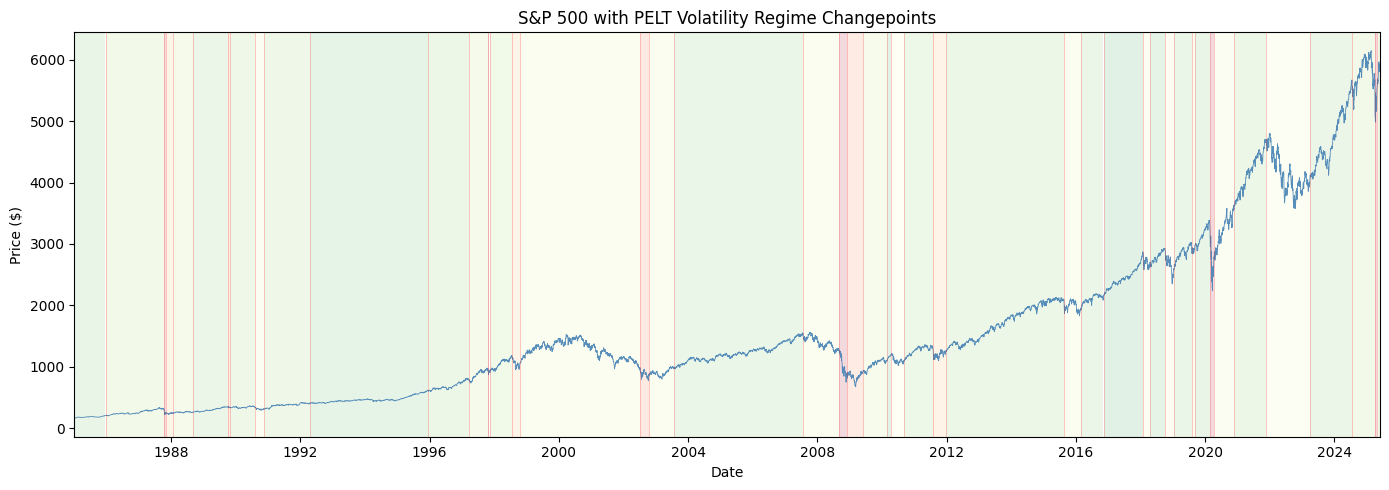

In [4]:
cmap = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close.index, close.values, color="steelblue", linewidth=0.6, alpha=0.9)

prev = 0
for b in breakpoints:
    seg = signal[prev:b]
    vol = np.std(seg)
    color = cmap(1 - min(vol / 0.03, 1))
    start_d = dates[prev] if prev < n else dates[-1]
    end_d = dates[min(b-1, n-1)]
    ax.axvspan(start_d, end_d, alpha=0.15, color=color, linewidth=0)
    prev = b

for d in cp_dates:
    ax.axvline(d, color="red", alpha=0.3, linewidth=0.5)

ax.set_title("S&P 500 with PELT Volatility Regime Changepoints")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

## 4. Daily Returns by Regime

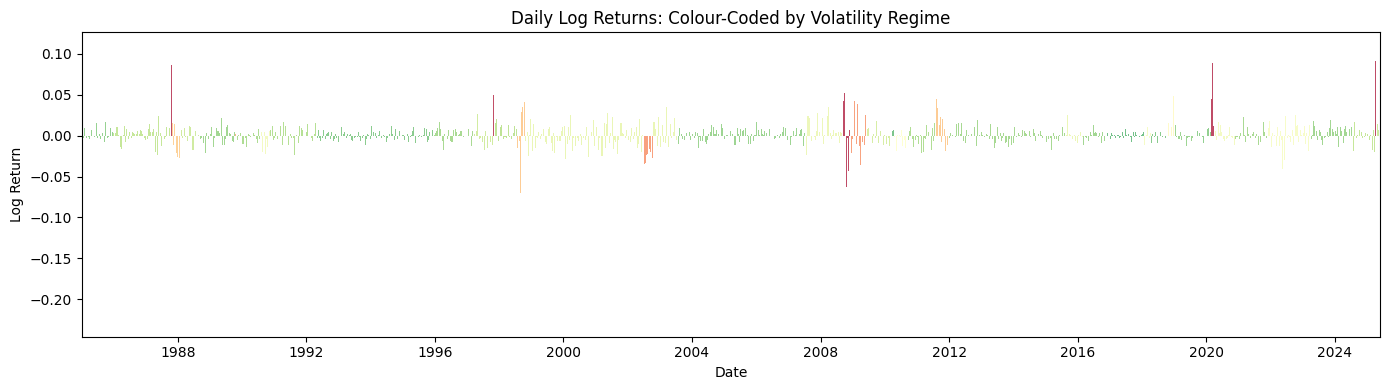

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
prev = 0
for b in breakpoints:
    seg = signal[prev:b]
    seg_dates = dates[prev:b]
    vol = np.std(seg)
    color = cmap(1 - min(vol / 0.03, 1))
    ax.bar(seg_dates, seg, width=1, color=color, alpha=0.7, linewidth=0)
    prev = b

ax.set_title("Daily Log Returns: Colour-Coded by Volatility Regime")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

## 5. Penalty Sensitivity
How the penalty parameter controls the number of changepoints.

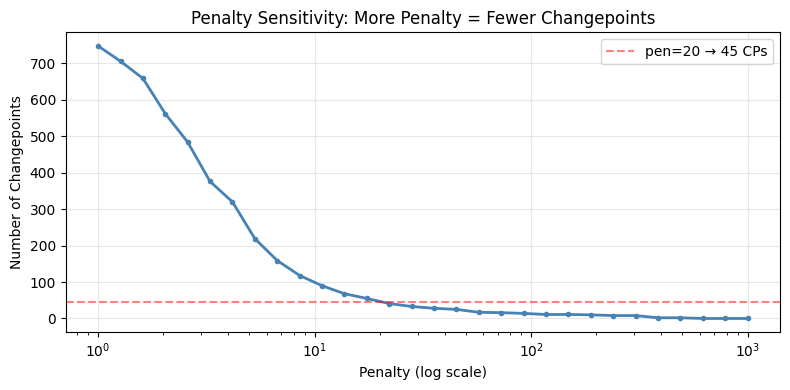

In [6]:
penalties = np.logspace(0, 3, 30)
n_cps = []
for p in penalties:
    bkps = algo.predict(pen=p)
    n_cps.append(len(bkps) - 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(penalties, n_cps, color="steelblue", linewidth=2, marker="o", markersize=3)
ax.set_xscale("log")
ax.set_xlabel("Penalty (log scale)")
ax.set_ylabel("Number of Changepoints")
ax.set_title("Penalty Sensitivity: More Penalty = Fewer Changepoints")
ax.axhline(n_cp, color="red", linestyle="--", alpha=0.5, label=f"pen={pen_main} \u2192 {n_cp} CPs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Regime Duration Analysis
How long do volatility regimes last?

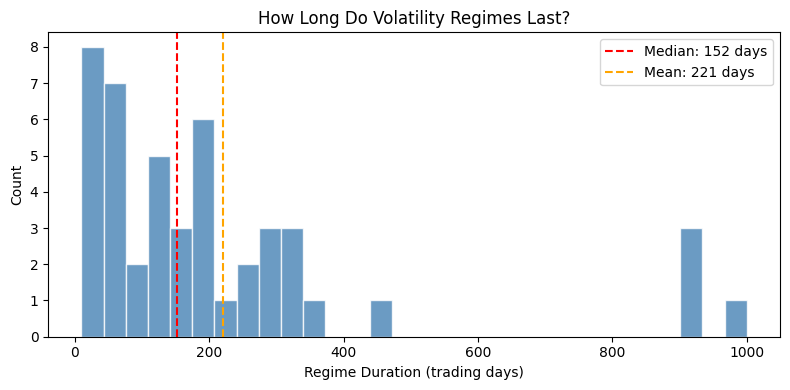

Median: 152 days, Mean: 221 days
Min: 10 days, Max: 1000 days


In [7]:
segments = [0] + list(breakpoints)
regime_lens = np.diff(segments)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(regime_lens, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(np.median(regime_lens), color="red", linestyle="--", linewidth=1.5,
           label=f"Median: {np.median(regime_lens):.0f} days")
ax.axvline(np.mean(regime_lens), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean: {np.mean(regime_lens):.0f} days")
ax.set_xlabel("Regime Duration (trading days)")
ax.set_ylabel("Count")
ax.set_title("How Long Do Volatility Regimes Last?")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median: {np.median(regime_lens):.0f} days, Mean: {np.mean(regime_lens):.0f} days")
print(f"Min: {np.min(regime_lens)} days, Max: {np.max(regime_lens)} days")

## 7. PELT vs Binary Segmentation
Compare the exact (PELT) and approximate (BinSeg) methods with the same number of changepoints.

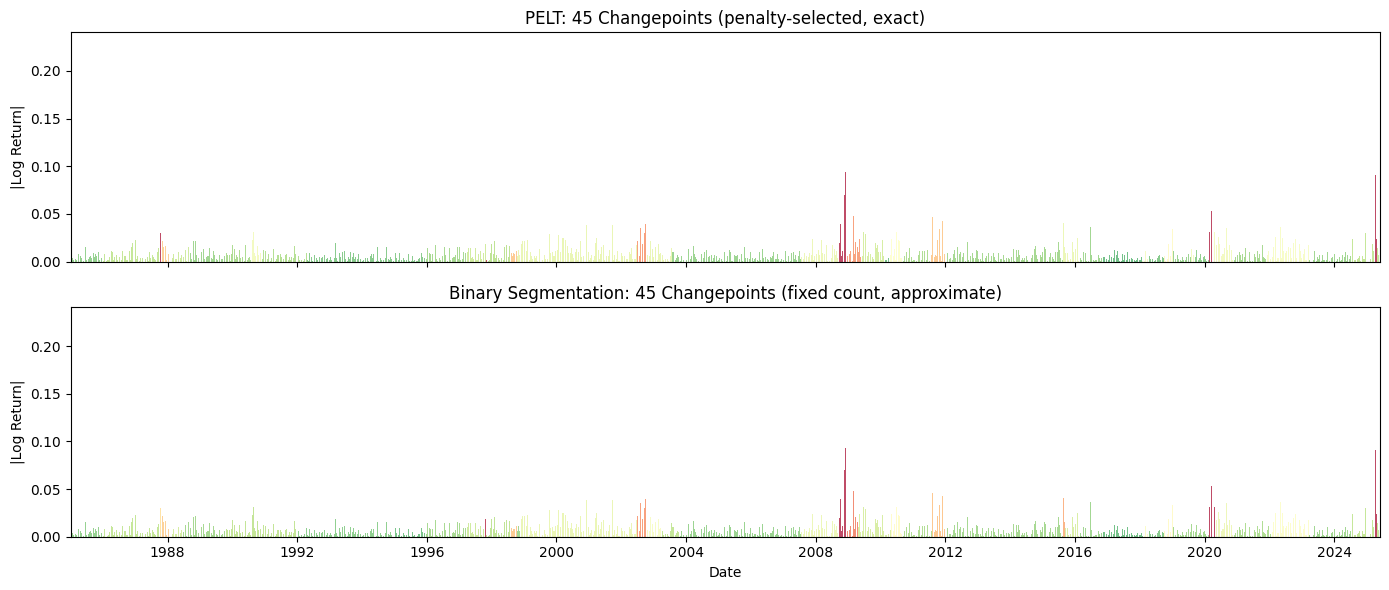

In [8]:
algo_bs = rpt.Binseg(model="normal", min_size=10, jump=5).fit(signal)
bkps_bs = algo_bs.predict(n_bkps=n_cp)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

prev = 0
for b in breakpoints:
    seg = signal[prev:b]
    seg_dates = dates[prev:b]
    vol = np.std(seg)
    color = cmap(1 - min(vol / 0.03, 1))
    ax1.bar(seg_dates, np.abs(seg), width=1, color=color, alpha=0.7, linewidth=0)
    prev = b
ax1.set_title(f"PELT: {n_cp} Changepoints (penalty-selected, exact)")
ax1.set_ylabel("|Log Return|")

prev = 0
for b in sorted(bkps_bs):
    seg = signal[prev:b]
    seg_dates = dates[prev:b]
    vol = np.std(seg)
    color = cmap(1 - min(vol / 0.03, 1))
    ax2.bar(seg_dates, np.abs(seg), width=1, color=color, alpha=0.7, linewidth=0)
    prev = b
ax2.set_title(f"Binary Segmentation: {n_cp} Changepoints (fixed count, approximate)")
ax2.set_ylabel("|Log Return|")
ax2.set_xlabel("Date")
ax2.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

## 8. Annotated Timeline: Changepoints and Financial Events
Using a higher penalty (50) for fewer, clearer changepoints.

Annotated: 23 changepoints (pen=50)


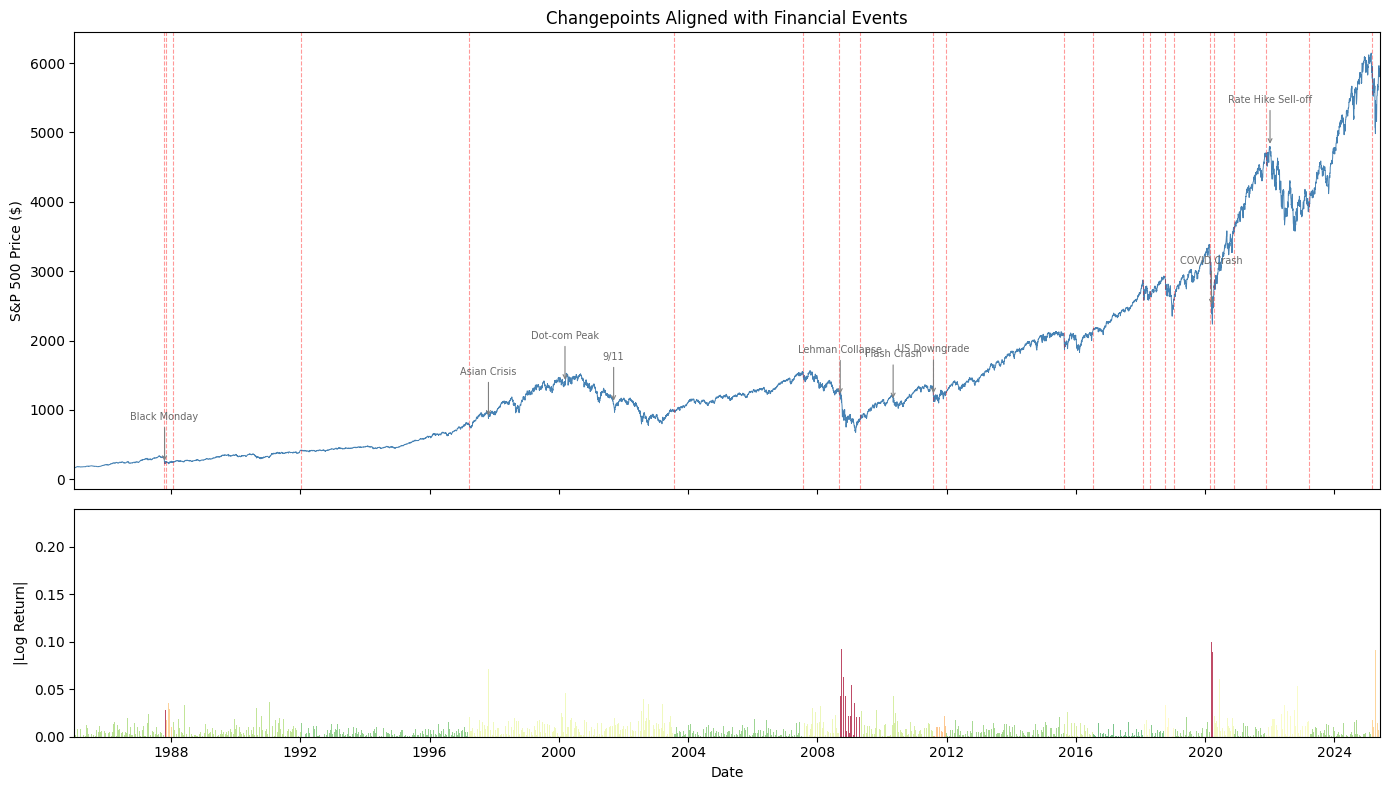

  Black Monday (1987-10-19): nearest CP at 1987-10-12 (-7 days)
  Asian Crisis (1997-10-27): nearest CP at 1997-03-25 (-216 days)
  Dot-com Peak (2000-03-10): nearest CP at 1997-03-25 (-1081 days)
  9/11 (2001-09-11): nearest CP at 2003-07-29 (+686 days)
  Lehman Collapse (2008-09-15): nearest CP at 2008-09-04 (-11 days)
  Flash Crash (2010-05-06): nearest CP at 2009-04-24 (-377 days)
  US Downgrade (2011-08-05): nearest CP at 2011-08-04 (-1 days)
  COVID Crash (2020-03-12): nearest CP at 2020-02-21 (-20 days)
  Rate Hike Sell-off (2022-01-03): nearest CP at 2021-11-24 (-40 days)


In [9]:
pen_anno = 50
bkps_anno = algo.predict(pen=pen_anno)
cp_dates_anno = [dates[min(b, n-1)] for b in bkps_anno[:-1]]
print(f"Annotated: {len(bkps_anno)-1} changepoints (pen={pen_anno})")

events = {
    pd.Timestamp("1987-10-19"): "Black Monday",
    pd.Timestamp("1997-10-27"): "Asian Crisis",
    pd.Timestamp("2000-03-10"): "Dot-com Peak",
    pd.Timestamp("2001-09-11"): "9/11",
    pd.Timestamp("2008-09-15"): "Lehman Collapse",
    pd.Timestamp("2010-05-06"): "Flash Crash",
    pd.Timestamp("2011-08-05"): "US Downgrade",
    pd.Timestamp("2020-03-12"): "COVID Crash",
    pd.Timestamp("2022-01-03"): "Rate Hike Sell-off",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(close.index, close.values, color="steelblue", linewidth=0.7)
for d in cp_dates_anno:
    ax1.axvline(d, color="red", alpha=0.4, linewidth=0.8, linestyle="--")

for evt_date, evt_name in events.items():
    if evt_date >= dates[0] and evt_date <= dates[-1]:
        idx = close.index.get_indexer([evt_date], method="nearest")[0]
        price = close.iloc[idx]
        ax1.annotate(evt_name, xy=(evt_date, price),
                     xytext=(0, 30), textcoords="offset points",
                     fontsize=7, ha="center", va="bottom",
                     arrowprops=dict(arrowstyle="->", color="grey", lw=0.8),
                     color="dimgrey")

ax1.set_title("Changepoints Aligned with Financial Events")
ax1.set_ylabel("S&P 500 Price ($)")

prev = 0
for b in bkps_anno:
    seg = signal[prev:b]
    seg_dates = dates[prev:b]
    vol = np.std(seg)
    color = cmap(1 - min(vol / 0.03, 1))
    ax2.bar(seg_dates, np.abs(seg), width=1, color=color, alpha=0.7, linewidth=0)
    prev = b

ax2.set_ylabel("|Log Return|")
ax2.set_xlabel("Date")
ax2.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

# Print alignment with known events
for evt_date, evt_name in sorted(events.items()):
    nearest = min(cp_dates_anno, key=lambda d: abs(d - evt_date))
    delta = (nearest - evt_date).days
    print(f"  {evt_name} ({evt_date.date()}): nearest CP at {nearest.date()} ({delta:+d} days)")

## 9. Squared Returns: The Exponential Distribution Connection
The original R code worked with squared returns, which follow an approximately exponential distribution.

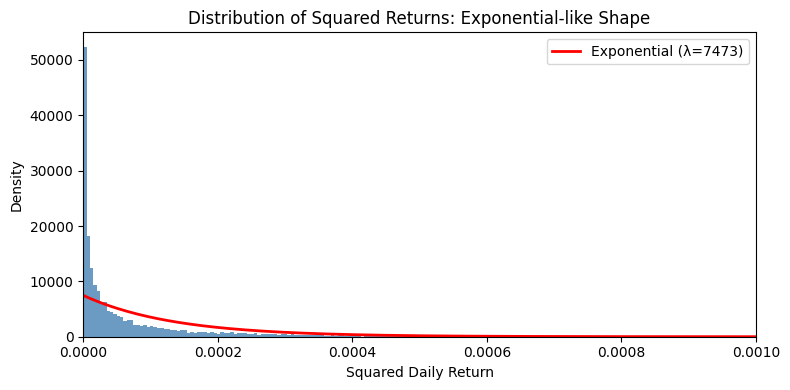

In [10]:
from scipy.stats import expon

sq_ret = (log_ret ** 2).values.reshape(-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sq_ret[sq_ret < 0.001], bins=200, color="steelblue", edgecolor="none", alpha=0.8, density=True)
lam = 1.0 / np.mean(sq_ret)
x_fit = np.linspace(0, 0.001, 200)
ax.plot(x_fit, expon.pdf(x_fit, scale=1/lam), color="red", linewidth=2,
        label=f"Exponential (\u03bb={lam:.0f})")
ax.set_xlabel("Squared Daily Return")
ax.set_ylabel("Density")
ax.set_title("Distribution of Squared Returns: Exponential-like Shape")
ax.legend()
ax.set_xlim(0, 0.001)
plt.tight_layout()
plt.show()